In [ ]:
import pandas as pd

In [346]:
df=pd.read_csv(r"train.csv")

In [347]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [348]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [349]:
df.shape

(891, 12)

In [350]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [351]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [352]:
df.duplicated().sum()

0

In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [354]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [355]:
numerical=[i for i in df.columns if df[i].dtype!='O']
numerical

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [356]:
categorical=[i for i in df.columns if df[i].dtype=='O']
categorical

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [357]:
df_numerical=df.select_dtypes(include=[int,float])
corr = df_numerical.corr()
corr.T

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

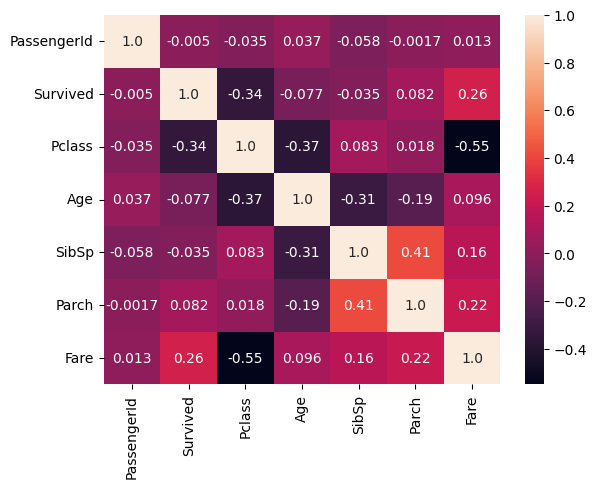

In [358]:
import seaborn as sns
sns.heatmap(corr,annot=True,fmt="0.2")

In [359]:
df.drop("Cabin",inplace=True,axis=1)

In [360]:
df.drop("PassengerId",inplace=True,axis=1)

In [361]:
df.drop("Name",inplace=True,axis=1)

In [362]:
df.drop("Ticket",inplace=True,axis=1)

In [363]:
df.dropna(inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [364]:
df.shape

(712, 8)

In [365]:
df.duplicated().sum()

38

In [366]:
df.drop_duplicates(inplace=True)

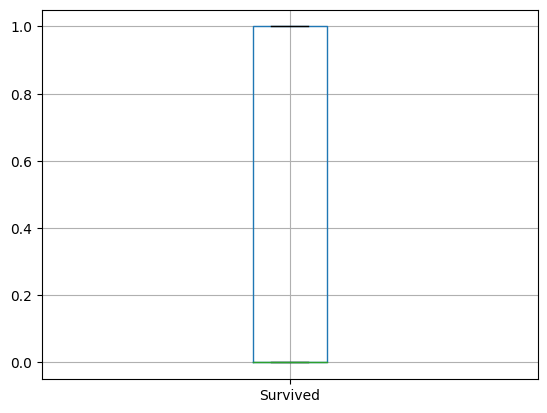

----------------------------------------------------------------------------------------------------


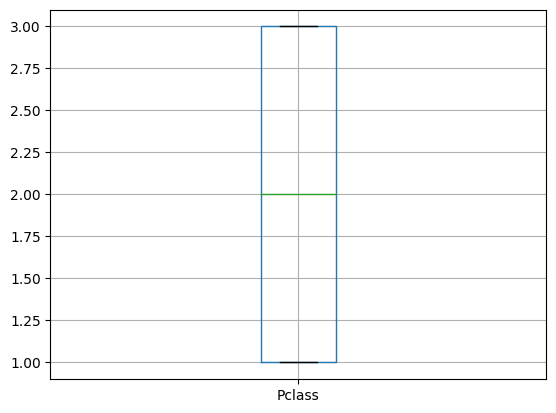

----------------------------------------------------------------------------------------------------


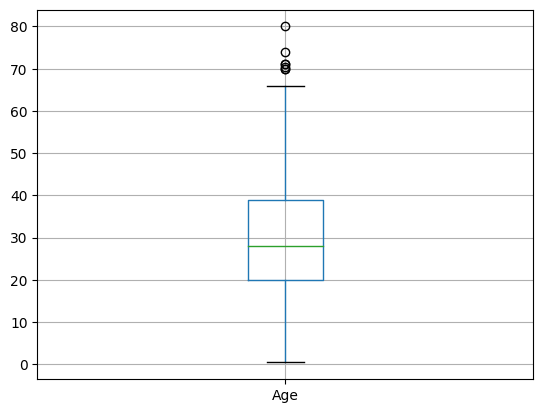

----------------------------------------------------------------------------------------------------


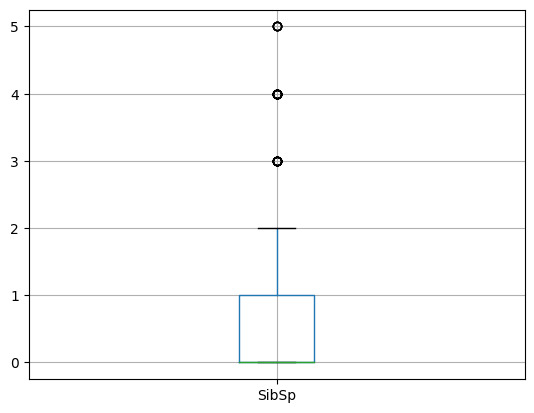

----------------------------------------------------------------------------------------------------


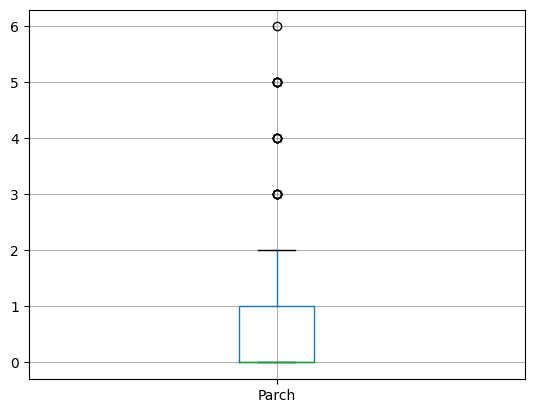

----------------------------------------------------------------------------------------------------


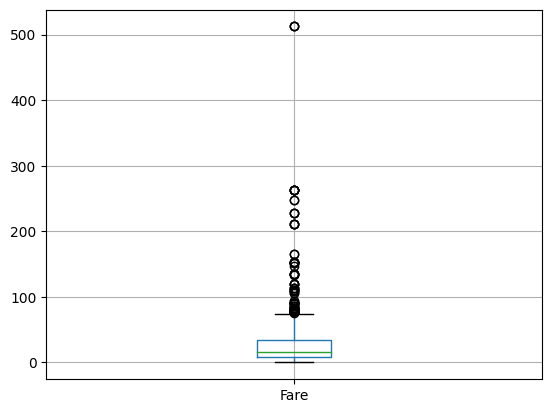

----------------------------------------------------------------------------------------------------


In [367]:
import matplotlib.pyplot as plt

for i in df.columns:
    if df[i].dtype in ['float64', 'int64']:
        df.boxplot(column=i)
        plt.show()
        print("-"*100)


In [368]:
for i in df.columns:
    print(i,"contain ",df[i].value_counts())
    print("----------------------------------------------------------------")

Survived contain  Survived
0    393
1    281
Name: count, dtype: int64
----------------------------------------------------------------
Pclass contain  Pclass
3    334
1    182
2    158
Name: count, dtype: int64
----------------------------------------------------------------
Sex contain  Sex
male      421
female    253
Name: count, dtype: int64
----------------------------------------------------------------
Age contain  Age
24.00    29
18.00    25
22.00    24
19.00    23
28.00    22
         ..
36.50     1
0.92      1
23.50     1
55.50     1
74.00     1
Name: count, Length: 88, dtype: int64
----------------------------------------------------------------
SibSp contain  SibSp
0    434
1    181
2     24
4     18
3     12
5      5
Name: count, dtype: int64
----------------------------------------------------------------
Parch contain  Parch
0    482
1    109
2     68
5      5
3      5
4      4
6      1
Name: count, dtype: int64
-----------------------------------------------------------

In [369]:
for i in df.columns :
    print(i,"contain", len(df[i].unique()))

Survived contain 2
Pclass contain 3
Sex contain 2
Age contain 88
SibSp contain 6
Parch contain 7
Fare contain 219
Embarked contain 3


In [370]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 674 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  674 non-null    int64  
 1   Pclass    674 non-null    int64  
 2   Sex       674 non-null    object 
 3   Age       674 non-null    float64
 4   SibSp     674 non-null    int64  
 5   Parch     674 non-null    int64  
 6   Fare      674 non-null    float64
 7   Embarked  674 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 47.4+ KB


In [371]:
Q1=df["Age"].quantile(0.25)
Q3=df["Age"].quantile(0.75)
iqr=Q3-Q1
max=Q3+(iqr*1.5)
min=Q1-(iqr*1.5)
print(f"max is : {max}")
print(f"min is : {min}")
outlayer=df[df["Age"]>max]
df=df[df["Age"]<=max]
print(f"shape of outlayer {outlayer.shape}")
print(f"shape of data  {df.shape}")

max is : 67.5
min is : -8.5
shape of outlayer (7, 8)
shape of data  (667, 8)


In [372]:
Q1=df["SibSp"].quantile(0.25)
Q3=df["SibSp"].quantile(0.75)
iqr=Q3-Q1
max=Q3+(iqr*1.5)
min=Q1-(iqr*1.5)
print(f"max is : {max}")
print(f"min is : {min}")
outlayer=df[df["SibSp"]>max]
df=df[df["SibSp"]<=max]
print(f"shape of outlayer {outlayer.shape}")
print(f"shape of data  {df.shape}")

max is : 2.5
min is : -1.5
shape of outlayer (35, 8)
shape of data  (632, 8)


In [373]:
Q1=df["Parch"].quantile(0.25)
Q3=df["Parch"].quantile(0.75)
iqr=Q3-Q1
max=Q3+(iqr*1.5)
min=Q1-(iqr*1.5)
print(f"max is : {max}")
print(f"min is : {min}")
outlayer=df[df["Parch"]>max]
df=df[df["Parch"]<=max]
print(f"shape of outlayer {outlayer.shape}")
print(f"shape of data  {df.shape}")

max is : 0.625
min is : -0.375
shape of outlayer (158, 8)
shape of data  (474, 8)


In [374]:
Q1=df["Fare"].quantile(0.25)
Q3=df["Fare"].quantile(0.75)
iqr=Q3-Q1
max=Q3+(iqr*1.5)
min=Q1-(iqr*1.5)
print(f"max is : {max}")
print(f"min is : {min}")
outlayer=df[df["Fare"]>max]
df=df[df["Fare"]<=max]
print(f"shape of outlayer {outlayer.shape}")
print(f"shape of data  {df.shape}")

max is : 54.5313
min is : -20.085499999999996
shape of outlayer (70, 8)
shape of data  (404, 8)


In [375]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()


In [376]:
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])

In [377]:
X=df.drop("Survived",inplace=False,axis=1)
y=df["Survived"]

In [378]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44, shuffle =True)
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (323, 7)
X_test shape is  (81, 7)
y_train shape is  (323,)
y_test shape is  (81,)


In [379]:
from sklearn.linear_model import LogisticRegression

In [380]:
LogisticRegressionModel = LogisticRegression(penalty='l2',solver='sag',C=1.0,random_state=33)
LogisticRegressionModel.fit(X_train, y_train)

C:\Users\Sigma\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(random_state=33, solver='sag')

In [381]:
#Calculating Details
print('LogisticRegressionModel Train Score is : ' , LogisticRegressionModel.score(X_train, y_train))
print('LogisticRegressionModel Test Score is : ' , LogisticRegressionModel.score(X_test, y_test))

LogisticRegressionModel Train Score is :  0.7244582043343654
LogisticRegressionModel Test Score is :  0.7777777777777778


In [382]:
from sklearn.metrics import classification_report

In [383]:
y_pred=LogisticRegressionModel.predict(X_test)
ClassificationReport = classification_report(y_test,y_pred)
print('Classification Report is :\n ', ClassificationReport )

Classification Report is :
                precision    recall  f1-score   support

           0       0.77      0.96      0.86        56
           1       0.82      0.36      0.50        25

    accuracy                           0.78        81
   macro avg       0.79      0.66      0.68        81
weighted avg       0.79      0.78      0.75        81



In [384]:
from sklearn.ensemble import RandomForestClassifier

In [385]:
RandomForestClassifierModel = RandomForestClassifier(criterion = 'gini',n_estimators=100,max_depth=2,random_state=33) #criterion can be also : entropy 
RandomForestClassifierModel.fit(X_train, y_train)



RandomForestClassifier(max_depth=2, random_state=33)

In [386]:

print('RandomForestClassifierModel Train Score is : ' , RandomForestClassifierModel.score(X_train, y_train))
print('RandomForestClassifierModel Test Score is : ' , RandomForestClassifierModel.score(X_test, y_test))


RandomForestClassifierModel Train Score is :  0.7894736842105263
RandomForestClassifierModel Test Score is :  0.8148148148148148
RandomForestClassifierModel features importances are :  [0.11943956 0.39827379 0.14286768 0.02013129 0.         0.26395664
 0.05533105]
